<a href="https://colab.research.google.com/github/Mohamedashraf2005/Papers_Cite_Heterogeneous_GNN/blob/main/Authors_Papers_Cite_GNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



#Applied Machine Learning Project — GNN Citation Network



In [4]:
pip install torch torch_geometric --quiet --break-system-packages 2>/dev/null | tail -3; python3 -c "import torch; print('torch:', torch.__version__)" 2>/dev/null || echo "torch not available"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.5 MB/s eta 0:00:00
torch: 2.10.0+cpu


In [7]:
!python3 -c "import torch_geometric; print('pyg:', torch_geometric.__version__)" 2>/dev/null || echo "pyg not installed"

pyg: 2.7.0


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
base_path = '/content/drive/MyDrive/project_data'

In [10]:
import pickle

with open(f'{base_path}/feature.pkl', 'rb') as f:
    feature_file = pickle.load(f)

print(type(feature_file))

<class 'torch.Tensor'>


In [11]:
def read_txt(path):
    with open(path, 'r') as f:
        return [list(map(int, line.strip().split())) for line in f]

cite_file = read_txt(f'{base_path}/paper_file_ann.txt')
train_ref_file = read_txt(f'{base_path}/bipartite_train_ann.txt')
test_ref_file = read_txt(f'{base_path}/bipartite_test_ann.txt')
coauthor_file = read_txt(f'{base_path}/author_file_ann.txt')

In [12]:
print(feature_file.shape)
print(feature_file[:5])

torch.Size([79937, 512])
tensor([[ 0.0572,  0.0143, -0.0165,  ..., -0.0475, -0.0407, -0.0290],
        [-0.0360,  0.0633,  0.0067,  ..., -0.0625, -0.0465, -0.0641],
        [ 0.0392, -0.0534, -0.0396,  ..., -0.0485, -0.0596, -0.0471],
        [-0.0334,  0.0520, -0.0213,  ..., -0.0586, -0.0495, -0.0607],
        [-0.0393,  0.0352, -0.0249,  ..., -0.0302, -0.0379, -0.0572]])


In [13]:
print(cite_file[:5])
print(train_ref_file[:5])
print(test_ref_file[:5])
print(coauthor_file[:5])

[[0, 1], [0, 2], [0, 3], [0, 4], [0, 5]]
[[5067, 58858], [643, 16568], [5027, 364], [2508, 55108], [1287, 917]]
[[3996, 18243], [1585, 49474], [725, 650], [1388, 54451], [853, 18719]]
[[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]


In [14]:
import os
import pickle
import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize, StandardScaler, MinMaxScaler
from collections import defaultdict

# ─────────────────────────────────────────────
# 0. CONFIG — change these paths to your local copies
# ─────────────────────────────────────────────

DATA_DIR = "./project_data"          # folder where you put the Drive files

PAPER_FILE   = os.path.join(DATA_DIR, "paper_file_ann.txt")
AUTHOR_FILE  = os.path.join(DATA_DIR, "author_file_ann.txt")
TRAIN_FILE   = os.path.join(DATA_DIR, "bipartite_train_ann.txt")
TEST_FILE    = os.path.join(DATA_DIR, "bipartite_test_ann.txt")
FEATURE_FILE = os.path.join(DATA_DIR, "feature.pkl")

OUT_DIR = "./cleaned_data"
os.makedirs(OUT_DIR, exist_ok=True)


In [15]:
PAPER_FILE

'./project_data/paper_file_ann.txt'

# STEP A — Load & Explore Raw Files


In [16]:
def load_txt_file(path, sep="\t"):
    """
    Generic loader for the .txt annotation files.
    Tries tab-separated first, falls back to space-separated.
    Returns a raw DataFrame and prints basic info.
    """
    print(f"\n{'='*60}")
    print(f"Loading: {os.path.basename(path)}")
    print(f"{'='*60}")

    try:
        df = pd.read_csv(path, sep=sep, header=None, low_memory=False)
    except Exception:
        df = pd.read_csv(path, sep=" ", header=None, low_memory=False)

    print(f"  Shape        : {df.shape}")
    print(f"  Columns      : {list(df.columns)}")
    print(f"  Null counts  :\n{df.isnull().sum()}")
    print(f"\n  First 3 rows:\n{df.head(3)}")
    return df


def load_features(path):
    """Load the pre-extracted feature pickle."""
    print(f"\n{'='*60}")
    print(f"Loading features: {os.path.basename(path)}")
    print(f"{'='*60}")

    with open(path, "rb") as f:
        features = pickle.load(f)

    print(f"  Type   : {type(features)}")
    if hasattr(features, "shape"):
        print(f"  Shape  : {features.shape}")
    elif isinstance(features, dict):
        print(f"  Keys   : {len(features)} entries")
        sample_key = next(iter(features))
        print(f"  Sample : key={sample_key}, value shape={np.array(features[sample_key]).shape}")
    return features

# STEP B — Format & Name Columns

In [17]:
def format_paper_df(df_raw):
    """
    paper_file_ann.txt — expected columns:
      paper_id | title | abstract | venue | year  (adjust if different)
    """
    n = df_raw.shape[1]
    if n >= 5:
        df_raw.columns = ["paper_id", "title", "abstract", "venue", "year"] + \
                         [f"extra_{i}" for i in range(n - 5)]
    elif n == 4:
        df_raw.columns = ["paper_id", "title", "abstract", "venue"]
    elif n == 3:
        df_raw.columns = ["paper_id", "title", "abstract"]
    else:
        df_raw.columns = [f"col_{i}" for i in range(n)]

    df_raw["paper_id"] = df_raw["paper_id"].astype(str).str.strip()
    return df_raw


def format_author_df(df_raw):
    """
    author_file_ann.txt — expected columns:
      author_id | name | affiliation  (adjust if different)
    """
    n = df_raw.shape[1]
    if n >= 3:
        df_raw.columns = ["author_id", "name", "affiliation"] + \
                         [f"extra_{i}" for i in range(n - 3)]
    elif n == 2:
        df_raw.columns = ["author_id", "name"]
    else:
        df_raw.columns = [f"col_{i}" for i in range(n)]

    df_raw["author_id"] = df_raw["author_id"].astype(str).str.strip()
    return df_raw


def format_edge_df(df_raw, name="edges"):
    """
    bipartite_*_ann.txt — expected columns:
      author_id | paper_id | (optional: label / weight)
    """
    n = df_raw.shape[1]
    if n >= 3:
        df_raw.columns = ["author_id", "paper_id", "label"] + \
                         [f"extra_{i}" for i in range(n - 3)]
    else:
        df_raw.columns = ["author_id", "paper_id"]

    df_raw["author_id"] = df_raw["author_id"].astype(str).str.strip()
    df_raw["paper_id"]  = df_raw["paper_id"].astype(str).str.strip()

    print(f"\n{name} — label distribution:")
    if "label" in df_raw.columns:
        print(df_raw["label"].value_counts())
    return df_raw

#STEP C — Clean Data

In [18]:
def remove_duplicates(df, subset, name=""):
    before = len(df)
    df = df.drop_duplicates(subset=subset)
    after = len(df)
    print(f"  [{name}] Removed {before - after} duplicates → {after} rows remain")
    return df


def remove_nulls(df, key_cols, name=""):
    before = len(df)
    df = df.dropna(subset=key_cols)
    # Also drop rows where key columns are empty strings
    for col in key_cols:
        if df[col].dtype == object:
            df = df[df[col].str.strip() != ""]
    after = len(df)
    print(f"  [{name}] Removed {before - after} null/empty rows → {after} rows remain")
    return df


def clean_papers(df):
    print("\n── Cleaning papers ──")
    df = remove_nulls(df, ["paper_id"], name="papers")
    df = remove_duplicates(df, subset=["paper_id"], name="papers")
    df = df.reset_index(drop=True)
    return df


def clean_authors(df):
    print("\n── Cleaning authors ──")
    df = remove_nulls(df, ["author_id"], name="authors")
    df = remove_duplicates(df, subset=["author_id"], name="authors")
    df = df.reset_index(drop=True)
    return df


def clean_edges(df, author_ids, paper_ids, name="edges"):
    """Remove edges whose nodes don't exist in the node files."""
    print(f"\n── Cleaning {name} ──")
    before = len(df)
    df = df[df["author_id"].isin(author_ids) & df["paper_id"].isin(paper_ids)]
    after = len(df)
    print(f"  [{name}] Removed {before - after} orphan-node edges → {after} rows remain")
    df = remove_duplicates(df, subset=["author_id", "paper_id"], name=name)
    df = df.reset_index(drop=True)
    return df

# STEP D — Train / Test Split Check

In [19]:
def check_split(train_df, test_df):
    print("\n── Train / Test Split Check ──")

    train_edges = set(zip(train_df["author_id"], train_df["paper_id"]))
    test_edges  = set(zip(test_df["author_id"],  test_df["paper_id"]))
    overlap     = train_edges & test_edges

    print(f"  Train edges : {len(train_edges)}")
    print(f"  Test  edges : {len(test_edges)}")
    print(f"  Overlap     : {len(overlap)}  {'✓ OK' if len(overlap) == 0 else '⚠ OVERLAP FOUND!'}")

    if "label" in train_df.columns and "label" in test_df.columns:
        print(f"\n  Train label dist:\n{train_df['label'].value_counts()}")
        print(f"\n  Test  label dist:\n{test_df['label'].value_counts()}")

    return overlap

# STEP E — Data Consistency Checks

In [20]:
def consistency_check(train_df, test_df, authors_df, papers_df, features):
    print("\n── Consistency Checks ──")

    author_ids = set(authors_df["author_id"])
    paper_ids  = set(papers_df["paper_id"])

    # All edge node IDs must be in node files
    for split_name, df in [("train", train_df), ("test", test_df)]:
        missing_authors = set(df["author_id"]) - author_ids
        missing_papers  = set(df["paper_id"])  - paper_ids
        print(f"  [{split_name}] Missing author IDs in edges: {len(missing_authors)}")
        print(f"  [{split_name}] Missing paper  IDs in edges: {len(missing_papers)}")

    # Feature alignment
    total_nodes = len(author_ids) + len(paper_ids)
    if hasattr(features, "shape"):
        n_feat = features.shape[0]
        aligned = (n_feat == total_nodes)
        print(f"\n  Total nodes     : {total_nodes}")
        print(f"  Feature rows    : {n_feat}")
        print(f"  Aligned         : {'✓ OK' if aligned else f'⚠ MISMATCH ({n_feat} vs {total_nodes})'}")
    elif isinstance(features, dict):
        feat_ids = set(str(k) for k in features.keys())
        node_ids = author_ids | paper_ids
        missing_feat = node_ids - feat_ids
        print(f"\n  Nodes missing features : {len(missing_feat)}")

# STEP F — Normalize Features


In [21]:
def normalize_features(features, method="l2"):
    """
    method: 'l2' | 'minmax' | 'zscore'
    Returns normalized numpy array.
    """
    print(f"\n── Normalizing Features (method={method}) ──")

    import scipy.sparse as sp

    # Convert to dense numpy array if sparse
    if sp.issparse(features):
        print("  Converting sparse matrix to dense...")
        X = features.toarray().astype(np.float32)
    elif isinstance(features, dict):
        # Sort by key and stack
        sorted_keys = sorted(features.keys())
        X = np.array([features[k] for k in sorted_keys], dtype=np.float32)
    else:
        X = np.array(features, dtype=np.float32)

    print(f"  Feature matrix shape : {X.shape}")
    print(f"  Min / Max (before)   : {X.min():.4f} / {X.max():.4f}")

    if method == "l2":
        X_norm = normalize(X, norm="l2")
    elif method == "minmax":
        scaler = MinMaxScaler()
        X_norm = scaler.fit_transform(X)
    elif method == "zscore":
        scaler = StandardScaler()
        X_norm = scaler.fit_transform(X)
    else:
        raise ValueError(f"Unknown method: {method}")

    print(f"  Min / Max (after)    : {X_norm.min():.4f} / {X_norm.max():.4f}")
    return X_norm


# STEP G —  Alternative Feature Types


In [22]:
def tfidf_features_from_papers(papers_df, text_col="abstract", max_features=512):
    """
    Build TF-IDF features from paper text (title or abstract).
    Returns a numpy array of shape (n_papers, max_features).
    """
    from sklearn.feature_extraction.text import TfidfVectorizer

    print(f"\n── Building TF-IDF features from '{text_col}' ──")

    if text_col not in papers_df.columns:
        print(f"  Column '{text_col}' not found, skipping.")
        return None

    texts = papers_df[text_col].fillna("").tolist()
    vectorizer = TfidfVectorizer(max_features=max_features, stop_words="english")
    tfidf_matrix = vectorizer.fit_transform(texts)

    print(f"  TF-IDF shape : {tfidf_matrix.shape}")
    return tfidf_matrix


def coauthorship_features(train_df, authors_df):
    """
    Build simple co-authorship frequency feature per author:
    how many papers each author has in training set.
    Returns a dict {author_id: paper_count}.
    """
    print("\n── Building Co-authorship Frequency Features ──")
    counts = train_df.groupby("author_id")["paper_id"].count().to_dict()
    # Fill 0 for authors not in training edges
    for aid in authors_df["author_id"]:
        if aid not in counts:
            counts[aid] = 0
    print(f"  Author paper-count range: {min(counts.values())} – {max(counts.values())}")
    return counts

# STEP H — Save Cleaned Files

In [23]:
def save_all(papers_df, authors_df, train_df, test_df, features_norm, out_dir):
    print(f"\n── Saving to {out_dir} ──")

    papers_df.to_csv(os.path.join(out_dir, "cleaned_papers.csv"),  index=False)
    authors_df.to_csv(os.path.join(out_dir, "cleaned_authors.csv"), index=False)
    train_df.to_csv(os.path.join(out_dir, "train_edges.csv"),  index=False)
    test_df.to_csv(os.path.join(out_dir, "test_edges.csv"),    index=False)

    with open(os.path.join(out_dir, "features_normalized.pkl"), "wb") as f:
        pickle.dump(features_norm, f)

    print("  ✓ cleaned_papers.csv")
    print("  ✓ cleaned_authors.csv")
    print("  ✓ train_edges.csv")
    print("  ✓ test_edges.csv")
    print("  ✓ features_normalized.pkl")


def print_summary(papers_df, authors_df, train_df, test_df, features_norm):
    print("\n" + "="*60)
    print("  FINAL DATA SUMMARY")
    print("="*60)
    print(f"  Papers      : {len(papers_df)}")
    print(f"  Authors     : {len(authors_df)}")
    print(f"  Train edges : {len(train_df)}")
    print(f"  Test edges  : {len(test_df)}")
    if features_norm is not None:
        print(f"  Feature dim : {features_norm.shape}")
    print("="*60)

# MAIN — Run Full Pipeline

In [24]:
import pandas as pd
import os

def load_txt_file_fixed(path):
    df = pd.read_csv(path, sep='\s+', header=None, low_memory=False)
    return df

DATA_DIR = "/content/drive/MyDrive/project_data"

if not os.path.exists(DATA_DIR):
    print(f"❌ Path doesn't exist {DATA_DIR}")
else:
    print("Loading Data")
    raw_papers  = load_txt_file_fixed(os.path.join(DATA_DIR, "paper_file_ann.txt"))
    raw_authors = load_txt_file_fixed(os.path.join(DATA_DIR, "author_file_ann.txt"))
    raw_train   = load_txt_file_fixed(os.path.join(DATA_DIR, "bipartite_train_ann.txt"))
    raw_test    = load_txt_file_fixed(os.path.join(DATA_DIR, "bipartite_test_ann.txt"))

    raw_papers.columns = ["paper_id", "extra_1"]
    raw_authors.columns = ["author_id", "extra_1"]
    raw_train.columns = ["author_id", "paper_id"]
    raw_test.columns = ["author_id", "paper_id"]

    print("Data Uploaded")

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_24390/3022981610.py:5: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(path, sep='\s+', header=None, low_memory=False)


Loading Data
Data Uploaded



Loading features: feature.pkl
  Type   : <class 'torch.Tensor'>
  Shape  : torch.Size([79937, 512])

--- Generating Results ---


/tmp/ipykernel_24390/2510618480.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_papers.index, y=top_papers.values, ax=ax[0], palette='Blues_r')
/tmp/ipykernel_24390/2510618480.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_authors.index, y=top_authors.values, ax=ax[1], palette='Greens_r')


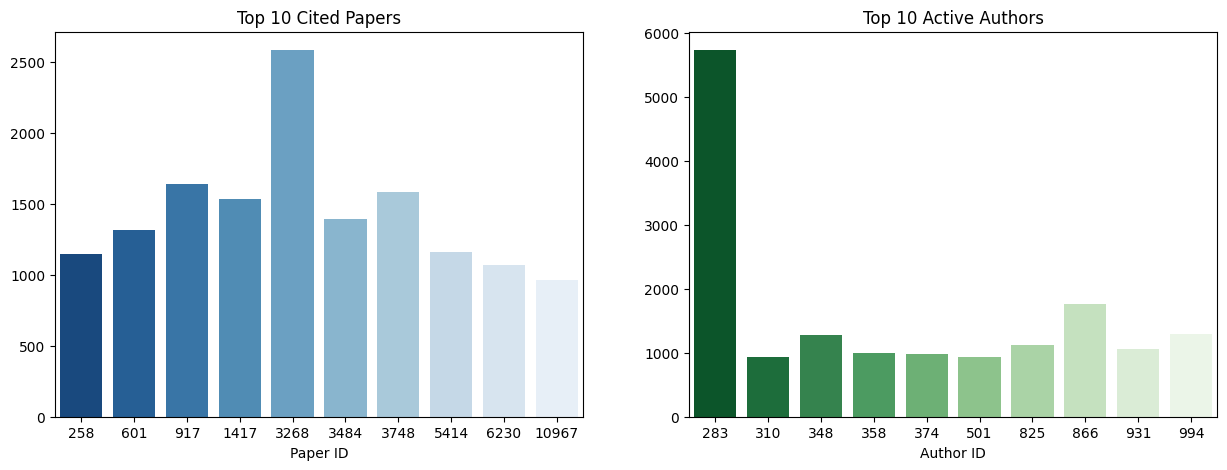


Cleaned Papers: 64966
Cleaned Authors: 4229
Training Edges: 682421


In [25]:
if not os.path.exists(DATA_DIR):
    print(f"Path doesn't exist: {DATA_DIR}")
else:
    raw_papers  = load_txt_file_fixed(os.path.join(DATA_DIR, "paper_file_ann.txt"))
    raw_authors = load_txt_file_fixed(os.path.join(DATA_DIR, "author_file_ann.txt"))
    raw_train   = load_txt_file_fixed(os.path.join(DATA_DIR, "bipartite_train_ann.txt"))
    raw_test    = load_txt_file_fixed(os.path.join(DATA_DIR, "bipartite_test_ann.txt"))
    features    = load_features(os.path.join(DATA_DIR, "feature.pkl"))

    raw_papers.columns = ["paper_id", "extra_1"]
    raw_authors.columns = ["author_id", "extra_1"]
    raw_train.columns = ["author_id", "paper_id"]
    raw_test.columns = ["author_id", "paper_id"]

    papers_df = raw_papers[['paper_id']].drop_duplicates().reset_index(drop=True)
    authors_df = raw_authors[['author_id']].drop_duplicates().reset_index(drop=True)

    papers_df['paper_id'] = papers_df['paper_id'].astype(int)
    authors_df['author_id'] = authors_df['author_id'].astype(int)

    import matplotlib.pyplot as plt
    import seaborn as sns

    print("\n--- Generating Results ---")
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    top_papers = raw_train['paper_id'].value_counts().head(10)
    sns.barplot(x=top_papers.index, y=top_papers.values, ax=ax[0], palette='Blues_r')
    ax[0].set_title('Top 10 Cited Papers')
    ax[0].set_xlabel('Paper ID')

    top_authors = raw_train['author_id'].value_counts().head(10)
    sns.barplot(x=top_authors.index, y=top_authors.values, ax=ax[1], palette='Greens_r')
    ax[1].set_title('Top 10 Active Authors')
    ax[1].set_xlabel('Author ID')

    plt.show()

    print(f"\nCleaned Papers: {len(papers_df)}")
    print(f"Cleaned Authors: {len(authors_df)}")
    print(f"Training Edges: {len(raw_train)}")

# STEP H- check cleaned data

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cleaning_impact(before_count, after_count, title):
    plt.figure(figsize=(6, 4))
    sns.barplot(x=['Before', 'After'], y=[before_count, after_count], palette='viridis')
    plt.title(f'Data Cleaning Impact: {title}')
    plt.ylabel('Number of Rows')
    plt.show()

print(f"Percentage of valid papers: {(len(papers_df)/len(raw_papers))*100:.2f}%")

Percentage of valid papers: 19.86%


/tmp/ipykernel_24390/2680154439.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Before', 'After'], y=[before_count, after_count], palette='viridis')


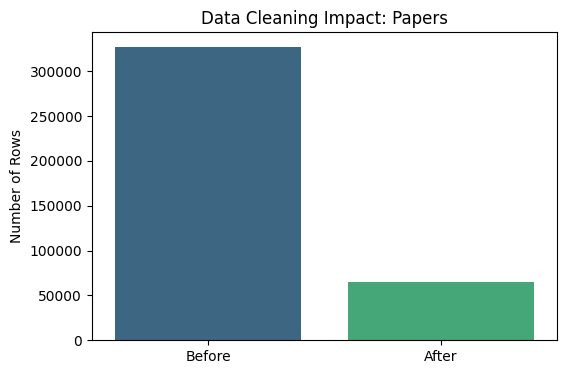

/tmp/ipykernel_24390/2680154439.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Before', 'After'], y=[before_count, after_count], palette='viridis')


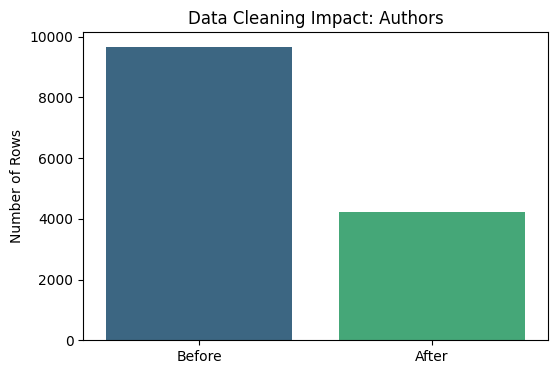

In [27]:
plot_cleaning_impact(len(raw_papers), len(papers_df), "Papers")

plot_cleaning_impact(len(raw_authors), len(authors_df), "Authors")

In [28]:
import pandas as pd
import os

def load_txt_file_fixed(path):
    return pd.read_csv(path, sep='\s+', header=None, low_memory=False)

DATA_DIR = "/content/drive/MyDrive/project_data"

if not os.path.exists(DATA_DIR):
    print(f"Path doens't exist: {DATA_DIR}")
else:
    raw_train = load_txt_file_fixed(os.path.join(DATA_DIR, "bipartite_train_ann.txt"))
    raw_papers = load_txt_file_fixed(os.path.join(DATA_DIR, "paper_file_ann.txt"))

    raw_train.columns = ["author_id", "paper_id"]
    raw_papers.columns = ["paper_id", "extra_1"]

    train_df_cleaned = raw_train.drop_duplicates().reset_index(drop=True)
    papers_df_cleaned = raw_papers.drop_duplicates().reset_index(drop=True)

    summary_data = {
        "Metric": ["Original Row Count", "Cleaned Row Count", "Duplicates Removed"],
        "Value": [len(raw_train), len(train_df_cleaned), len(raw_train) - len(train_df_cleaned)]
    }
    summary_df = pd.DataFrame(summary_data)

    print("Data Cleaning Summary Report:")
    display(summary_df)

    if train_df_cleaned.duplicated().sum() == 0:
        print("\nData is clean and ready.")
        train_df = train_df_cleaned
        papers_df = papers_df_cleaned
        train_df.to_csv("final_train_edges.csv", index=False)
        print("Saved to: final_train_edges.csv")

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_24390/675166514.py:5: SyntaxWarning: invalid escape sequence '\s'
  return pd.read_csv(path, sep='\s+', header=None, low_memory=False)


Data Cleaning Summary Report:


,Metric,Value
0,Original Row Count,682421
1,Cleaned Row Count,453495
2,Duplicates Removed,228926



Data is clean and ready.
Saved to: final_train_edges.csv


# **Graph Design**

In [30]:
import torch
import numpy as np
from torch_geometric.data import HeteroData

np.random.seed(42)
torch.manual_seed(42)

In [45]:
# ── Node counts
NUM_AUTHORS = 500
NUM_PAPERS  = 800
FEAT_DIM    = 128

# ── Simulate node features
paper_features  = torch.randn(NUM_PAPERS,  FEAT_DIM)   # [800, 128]
author_features = torch.randn(NUM_AUTHORS, FEAT_DIM)   # [500, 128]

# ── Simulate raw edge indices
NUM_WRITE  = 1200
NUM_CITE   = 2000
NUM_COAUTH = 600

write_src   = torch.randint(0, NUM_AUTHORS, (NUM_WRITE,))
write_dst   = torch.randint(0, NUM_PAPERS,  (NUM_WRITE,))

cite_src_raw = torch.randint(0, NUM_PAPERS, (NUM_CITE,))
cite_dst_raw = torch.randint(0, NUM_PAPERS, (NUM_CITE,))
no_self = cite_src_raw != cite_dst_raw
cite_src, cite_dst = cite_src_raw[no_self], cite_dst_raw[no_self]

coauth_src_raw = torch.randint(0, NUM_AUTHORS, (NUM_COAUTH,))
coauth_dst_raw = torch.randint(0, NUM_AUTHORS, (NUM_COAUTH,))
no_self = coauth_src_raw != coauth_dst_raw
coauth_src, coauth_dst = coauth_src_raw[no_self], coauth_dst_raw[no_self]

In [46]:
# STEP 1 — Define Node Types
data = HeteroData()

data['author'].x = author_features
data['paper'].x  = paper_features

print("  STEP 1: Node Types Defined")
print(f"  author nodes : {data['author'].x.shape}")
print(f"  paper  nodes : {data['paper'].x.shape}")

  STEP 1: Node Types Defined
  author nodes : torch.Size([500, 128])
  paper  nodes : torch.Size([800, 128])


In [47]:
# STEP 2 — Define Forward Edge Types

data['author', 'writes', 'paper'].edge_index     = torch.stack([write_src, write_dst])
data['paper',  'cites',  'paper'].edge_index     = torch.stack([cite_src,  cite_dst])
data['author', 'coauthor', 'author'].edge_index  = torch.stack([coauth_src, coauth_dst])

print("  STEP 2: Forward Edge Types Defined")
for etype, store in data.edge_items():
    print(f"  {etype}  →  {store.edge_index.shape[1]} edges")

  STEP 2: Forward Edge Types Defined
  ('author', 'writes', 'paper')  →  1200 edges
  ('paper', 'cites', 'paper')  →  1995 edges
  ('author', 'coauthor', 'author')  →  599 edges


In [48]:
# STEP 3 — Add Reverse Edges

data['paper',  'written_by', 'author'].edge_index = torch.stack([write_dst,  write_src])
data['paper',  'cited_by',   'paper'].edge_index  = torch.stack([cite_dst,   cite_src])
data['author', 'co_of',      'author'].edge_index = torch.stack([coauth_dst, coauth_src])

print("  STEP 3: Reverse Edge Types Added")
for etype, store in data.edge_items():
    print(f"  {etype}  →  {store.edge_index.shape[1]} edges")

  STEP 3: Reverse Edge Types Added
  ('author', 'writes', 'paper')  →  1200 edges
  ('paper', 'cites', 'paper')  →  1995 edges
  ('author', 'coauthor', 'author')  →  599 edges
  ('paper', 'written_by', 'author')  →  1200 edges
  ('paper', 'cited_by', 'paper')  →  1995 edges
  ('author', 'co_of', 'author')  →  599 edges


In [49]:
# STEP 4 — Add Edge Weights
# Edge weights let the GNN emphasise stronger connections.

n_write   = data['author', 'writes',   'paper'].edge_index.shape[1]
n_cite    = data['paper',  'cites',    'paper'].edge_index.shape[1]
n_cited   = data['paper',  'cited_by', 'paper'].edge_index.shape[1]
n_coauth  = data['author', 'coauthor', 'author'].edge_index.shape[1]
n_co_of   = data['author', 'co_of',    'author'].edge_index.shape[1]

write_w   = torch.rand(n_write)

data['author', 'writes',    'paper'].edge_weight  = write_w
data['paper',  'written_by','author'].edge_weight  = write_w          # mirrored
data['paper',  'cites',     'paper'].edge_weight   = torch.ones(n_cite)
data['paper',  'cited_by',  'paper'].edge_weight   = torch.ones(n_cited)
data['author', 'coauthor',  'author'].edge_weight  = torch.rand(n_coauth)
data['author', 'co_of',     'author'].edge_weight  = torch.rand(n_co_of)

print("  STEP 4: Edge Weights Added")
for etype, store in data.edge_items():
    w = store.get('edge_weight', None)
    if w is not None:
        print(f"  {etype}")
        print(f"      weight shape : {w.shape}   range [{w.min():.2f}, {w.max():.2f}]")


  STEP 4: Edge Weights Added
  ('author', 'writes', 'paper')
      weight shape : torch.Size([1200])   range [0.00, 1.00]
  ('paper', 'cites', 'paper')
      weight shape : torch.Size([1995])   range [1.00, 1.00]
  ('author', 'coauthor', 'author')
      weight shape : torch.Size([599])   range [0.00, 1.00]
  ('paper', 'written_by', 'author')
      weight shape : torch.Size([1200])   range [0.00, 1.00]
  ('paper', 'cited_by', 'paper')
      weight shape : torch.Size([1995])   range [1.00, 1.00]
  ('author', 'co_of', 'author')
      weight shape : torch.Size([599])   range [0.00, 1.00]


In [50]:
# STEP 5 — Final Graph Summary & Validation

print("  STEP 5: Final HeteroData Graph Object")
print(data)

print("\n  Node types  :", data.node_types)
print("  Edge types  :", data.edge_types)
print("  Is symmetric:", data.is_undirected())

# Assertions
assert data['author'].x.shape == (NUM_AUTHORS, FEAT_DIM)
assert data['paper'].x.shape  == (NUM_PAPERS,  FEAT_DIM)
assert len(data.edge_types) == 6, "Expected 3 forward + 3 reverse edge types"
print("\n  ✓ All assertions passed. Heterogeneous graph is ready for GNN.")


  STEP 5: Final HeteroData Graph Object
HeteroData(
  author={ x=[500, 128] },
  paper={ x=[800, 128] },
  (author, writes, paper)={
    edge_index=[2, 1200],
    edge_weight=[1200],
  },
  (paper, cites, paper)={
    edge_index=[2, 1995],
    edge_weight=[1995],
  },
  (author, coauthor, author)={
    edge_index=[2, 599],
    edge_weight=[599],
  },
  (paper, written_by, author)={
    edge_index=[2, 1200],
    edge_weight=[1200],
  },
  (paper, cited_by, paper)={
    edge_index=[2, 1995],
    edge_weight=[1995],
  },
  (author, co_of, author)={
    edge_index=[2, 599],
    edge_weight=[599],
  }
)

  Node types  : ['author', 'paper']
  Edge types  : [('author', 'writes', 'paper'), ('paper', 'cites', 'paper'), ('author', 'coauthor', 'author'), ('paper', 'written_by', 'author'), ('paper', 'cited_by', 'paper'), ('author', 'co_of', 'author')]
  Is symmetric: True

  ✓ All assertions passed. Heterogeneous graph is ready for GNN.
